# **Body Performance Classification and Clustering**

# **1. Problem**
This project focuses on analyzing human body performance data using data mining techniques. The dataset includes physical and fitness-related measurements that describe individuals' body performance. The aim of this project is to understand how these attributes affect overall body performance and to discover meaningful patterns in the data.

we want to:
* Classify individuals into performance levels (A, B, C, D) based on body performance attributes.
* Cluster individuals according to similarities in their physical fitness measurements.
# **2. Motivation**
Analyzing body performance data is important in health, fitness assessment, and sports science. This dataset was selected because it represents real-world physical performance measurements, includes clear class labels, and contains a sufficient number of records and attributes, making it suitable for data mining tasks such as classification and clustering.
# **3. Data mining task**
Both classification and clustering techniques are applied in this project. Classification is used to predict body performance levels, while clustering is used to group individuals with similar physical characteristics.

# **4. Data**
* Dataset Name: Body Performance Dataset
* Source: Kaggle
* File Format: CSV
* Number of Records: 13,393
* Number of Attributes: 12
* Class Label: class (A, B, C, D)

In [ ]:
import pandas as pd

df = pd.read_csv("bodyPerformance.csv")


print("Shape (rows, columns):", df.shape)


print("\nColumns:")
print(df.columns.tolist())


print("\nData Types:")
print(df.dtypes)


print("\nInfo:")
df.info()


print("\nClass label counts:")
print(df["class"].value_counts())


print("\nSample (first 5 rows):")
print(df.head())

Shape (rows, columns): (13393, 12)

Columns:
['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']

Data Types:
age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   heig

# **Body Performance Classification and Clustering**

# **Project Description**
This project focuses on analyzing human body performance data using data mining techniques. The dataset includes physical and fitness-related measurements that describe individuals' body performance. The aim of this project is to understand how these attributes affect overall body performance and to discover meaningful patterns in the data.

Both classification and clustering techniques are applied in this project. Classification is used to predict body performance levels, while clustering is used to group individuals with similar physical characteristics.

# **Project Goal**
* Classify individuals into performance levels (A, B, C, D) based on body performance attributes.
* Cluster individuals according to similarities in their physical fitness measurements.

# **Motivation**
Analyzing body performance data is important in health, fitness assessment, and sports science. This dataset was selected because it represents real-world physical performance measurements, includes clear class labels, and contains a sufficient number of records and attributes, making it suitable for data mining tasks such as classification and clustering.

# **Dataset Information**
* Dataset Name: Body Performance Dataset
* Source: Kaggle
* File Format: CSV
* Number of Records: 13,393
* Number of Attributes: 12
* Class Label: class (A, B, C, D)

In [ ]:

import pandas as pd
import numpy as np

df = pd.read_csv("bodyPerformance.csv")

df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:

df.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


The dataset contains 13,393 observations. The statistical summary shows the mean, standard deviation, minimum, quartiles, and maximum for all numeric attributes.

The variable “sit and bend forward_cm” contains negative values, which may represent flexibility test results.

Some attributes show a large gap between the 75th percentile and maximum value (e.g., weight_kg, systolic, broad jump_cm), which may indicate the presence of outliers.

#**4. Data Preprocessing**

In this phase, data preprocessing techniques are applied to prepare the dataset for analysis. This includes exploring the data, handling missing values, detecting outliers, and transforming the data into a suitable format for data mining models.

The following steps include statistical summaries and analysis of numerical features to better understand the data distribution.

In [ ]:

numeric_cols = df.select_dtypes(include=np.number)

five_number_summary = numeric_cols.describe().loc[['min','25%','50%','75%','max']]
five_number_summary

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
min,21.0,125.0,26.3,3.0,0.0,0.0,0.0,-25.0,0.0,0.0
25%,25.0,162.4,58.2,18.0,71.0,120.0,27.5,10.9,30.0,162.0
50%,32.0,169.2,67.4,22.8,79.0,130.0,37.9,16.2,41.0,193.0
75%,48.0,174.8,75.3,28.0,86.0,141.0,45.2,20.7,50.0,221.0
max,64.0,193.8,138.1,78.4,156.2,201.0,70.5,213.0,80.0,303.0


The five-number summary was calculated for all numeric attributes, including minimum, first quartile (Q1), median, third quartile (Q3), and maximum.

The results show variability in several attributes such as weight_kg, systolic, and broad jump_cm, where there is a large difference between Q3 and the maximum value.

The attribute "sit and bend forward_cm" includes negative values and a very large maximum value (213), indicating potential extreme values that may require further investigation.

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
height_cm,0
weight_kg,0
body fat_%,0
diastolic,0
systolic,0
gripForce,0
sit and bend forward_cm,0
sit-ups counts,0



The missing value analysis was performed using df.isnull().sum(). The results show that there are no missing values in any of the attributes.

This indicates that the dataset is complete and does not require missing value imputation or removal of incomplete records.

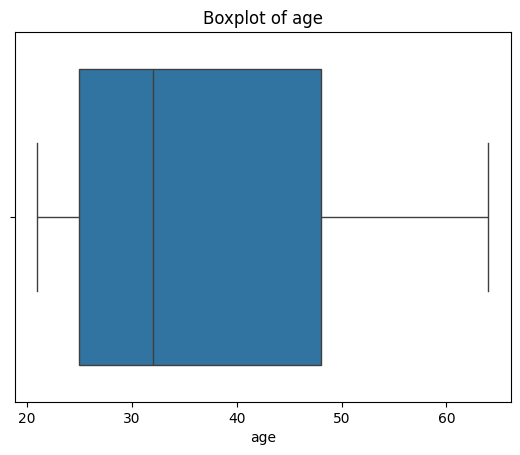

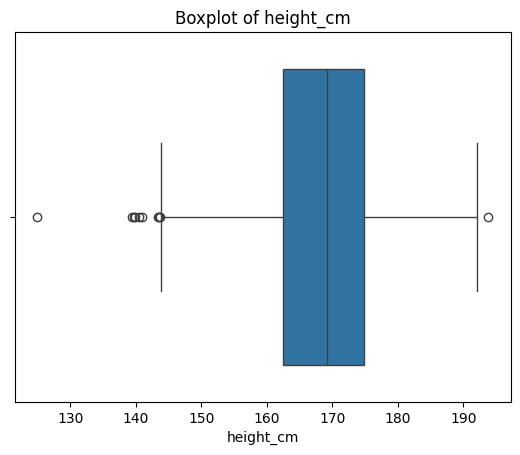

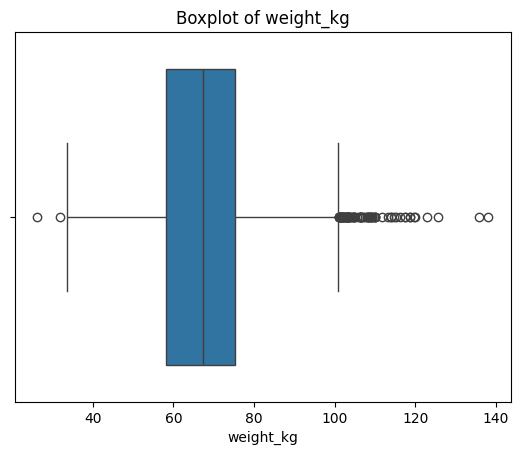

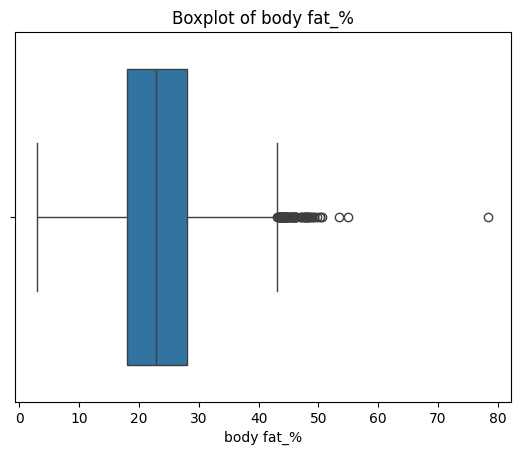

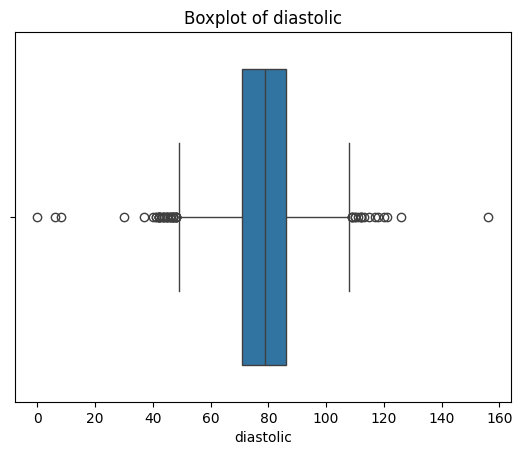

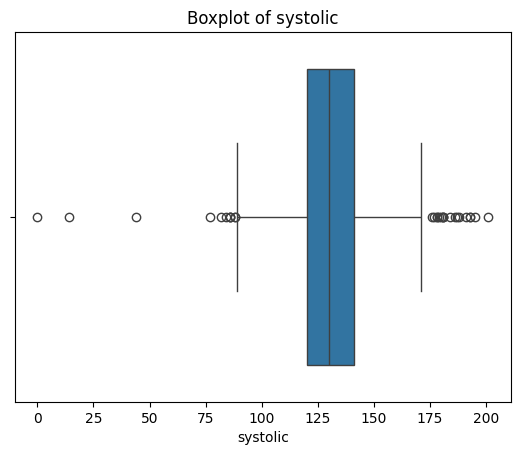

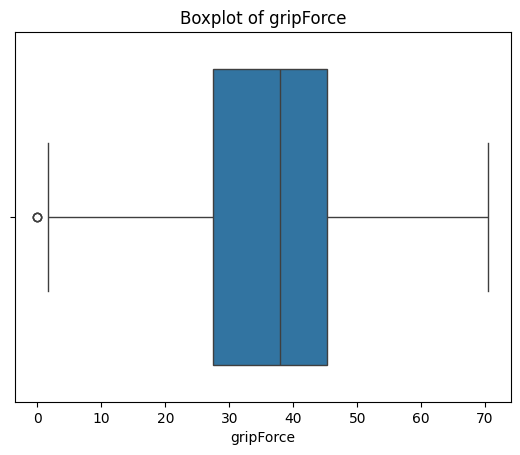

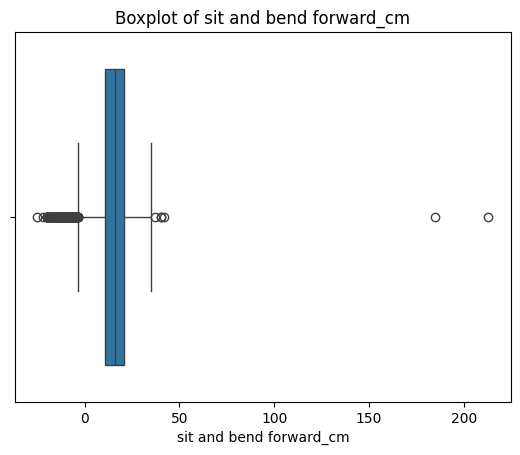

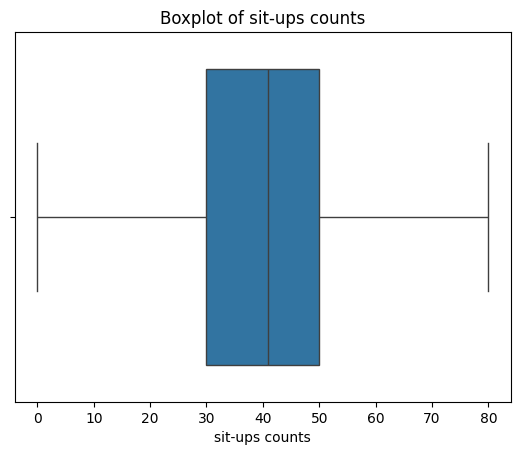

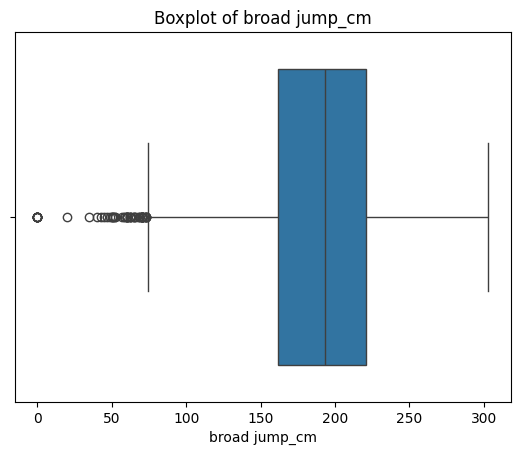

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=np.number)

for col in numeric_cols.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Boxplots were used to visually detect potential outliers in the dataset. Several attributes such as weight_kg, body fat_%, systolic, diastolic, and sit and bend forward_cm show noticeable outliers. In particular, sit and bend forward_cm contains extreme upper values exceeding 200 cm, which may require preprocessing Other attributes like age and sit-ups counts show relatively stable distributions with minimal outliers. These observations indicate that preprocessing techniques such as normalization or outlier handling may be required.

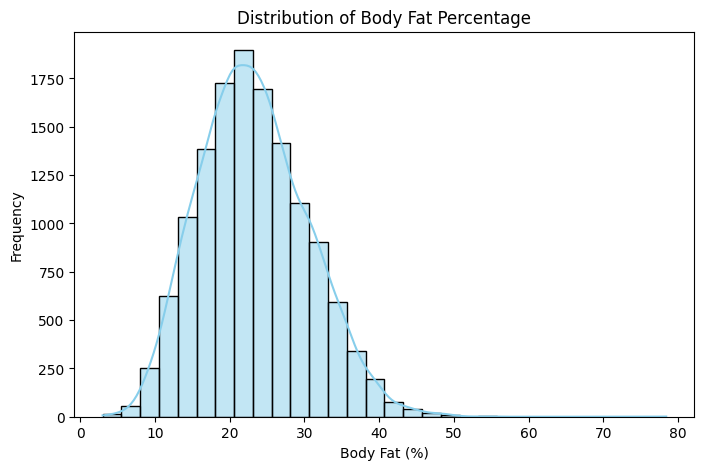

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='body fat_%', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Body Fat Percentage')
plt.xlabel('Body Fat (%)')
plt.ylabel('Frequency')
plt.show()

The histogram displays the distribution of the 'body fat_%' numeric attribute. As observed, the data exhibits a slight right skew, indicating the presence of potential outliers with unusually high body fat values (extending towards the 60-80 range). This non-normal distribution suggests that we need to apply Outlier Handling or Data Normalization during the preprocessing phase to prevent these extreme values from skewing the machine learning model's predictions.

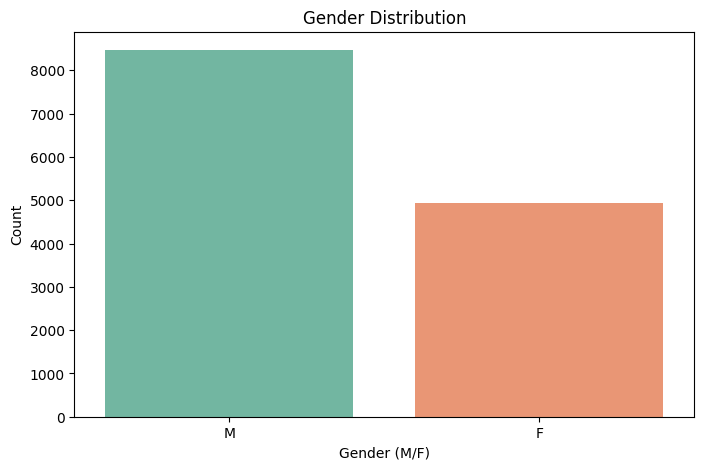

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender (M/F)')
plt.ylabel('Count')
plt.show()

This bar plot illustrates the distribution of nominal data, specifically the 'gender' attribute (Male vs. Female). Since machine learning models primarily require numerical inputs to perform calculations and find patterns, this nominal attribute explicitly dictates the need for Variable Transformation (such as Label Encoding or One-Hot Encoding) in the subsequent preprocessing step to convert letters (M/F) into numbers (0/1).

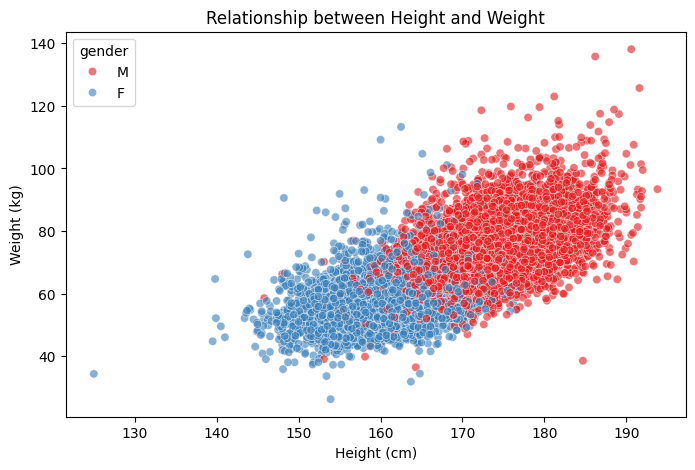

In [ ]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='height_cm', y='weight_kg', hue='gender', alpha=0.6, palette='Set1')
plt.title('Relationship between Height and Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

The scatter plot reveals the relationship between height and weight among the individuals in the dataset, categorized by gender. Notably, there are a few isolated data points lying far away from the main cluster (e.g., extremely high weight relative to an average height). These visually represent potential noise or physical outliers. Identifying these instances confirms that Noise Removal or outlier handling is required to improve overall data quality before training the model.

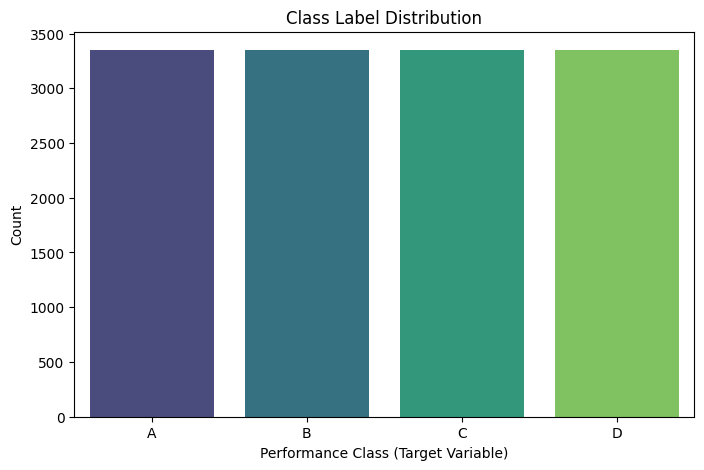

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', order=['A', 'B', 'C', 'D'], palette='viridis')
plt.title('Class Label Distribution')
plt.xlabel('Performance Class (Target Variable)')
plt.ylabel('Count')
plt.show()

This plot demonstrates the distribution of the target class labels (A, B, C, and D). Monitoring the class distribution is a critical step to ensure our predictive model doesn't become biased. Fortunately, the classes appear to be evenly balanced. However, similar to the gender attribute, these alphabetical labels (A-D) must be mapped and transformed into a numerical format (e.g., 0, 1, 2, 3) using Label Encoding during the preprocessing phase to be computationally interpretable by the target machine learning algorithm.



In [ ]:
df_raw = pd.read_csv("bodyPerformance.csv")
df = df_raw.copy()
df_raw.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

k = 3  # threshold
means = df[num_cols].mean()
stds  = df[num_cols].std()

lower = means - k * stds
upper = means + k * stds

df[num_cols] = df[num_cols].clip(lower=lower, upper=upper, axis=1)



Outliers were handled using the standard deviation method. Instead of removing data points, we applied clipping to limit extreme values within a reasonable range (mean ± 3 × standard deviation).

This approach reduces the impact of extreme values while preserving the dataset size, which helps maintain model performance.

In [ ]:
df_out=df.copy()
df_trans = df_out.copy()

df_trans["body fat_%_log"] = np.log1p(df_trans["body fat_%"])



A logarithmic transformation (log1p) was applied to the `body fat_%` feature to reduce skewness and make the data distribution more balanced.

This improves model performance since many machine learning models work better with normally distributed data.

In [ ]:
df_trans.isnull().sum()

,0
age,0
gender,0
height_cm,0
weight_kg,0
body fat_%,0
diastolic,0
systolic,0
gripForce,0
sit and bend forward_cm,0
sit-ups counts,0


We examined the dataset for missing values. No missing values were found, so no preprocessing action was needed.

In [ ]:
df["gender"] = df["gender"].map({"M": 1, "F": 0})
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


The gender column was converted into numerical values (Male = 1, Female = 0). This transformation was necessary because machine learning algorithms require numerical input rather than categorical text values.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


num_cols = df.select_dtypes(include=np.number).columns

num_cols = num_cols.drop("gender")

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,0.139535,1,0.574425,0.608688,0.435603,0.518667,0.497340,0.781355,0.562884,0.7500,0.630067,C
1,0.093023,1,0.429928,0.337550,0.302304,0.472121,0.452032,0.491155,0.521496,0.6625,0.681685,A
2,0.232558,1,0.718923,0.647182,0.407039,0.704852,0.746537,0.622921,0.436751,0.6125,0.475211,C
3,0.255814,1,0.617973,0.550945,0.366573,0.456606,0.689901,0.569587,0.499817,0.6625,0.638670,B
4,0.162791,1,0.604117,0.503524,0.335629,0.363514,0.463359,0.602529,0.734346,0.5625,0.630067,B


Min-Max normalization was applied to the numerical features to scale their values between 0 and 1. Categorical variables such as gender and the target variable (class) were excluded from scaling. This preprocessing step ensures that all numerical features have comparable ranges and prevents features with larger values from dominating the model.

In [ ]:
df.to_csv("Preprocessed_dataset.csv", index=False)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### **5. Data Mining Technique**
**5.1 (Classification)**

For the classification task, we chose the Decision Tree algorithm to predict the body performance class of individuals based on their physical attributes. Decision Trees are highly interpretable, visualize the decision-making process clearly, and do not require extensive data scaling. We utilized the scikit-learn (sklearn) library in Python, specifically the DecisionTreeClassifier() method. Following the project requirements, we experiment with both Gini Index and Entropy (Information Gain) as the attribute selection measures to evaluate the impurity of the splits. Furthermore, to understand the model's robustness, we split the dataset into three different training/testing partitions for each measure: 90% Training / 10% Testing, 80% Training / 20% Testing, and 70% Training / 30% Testing.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Preprocessed_dataset.csv')

X = df.drop('class', axis=1)
y = df['class']

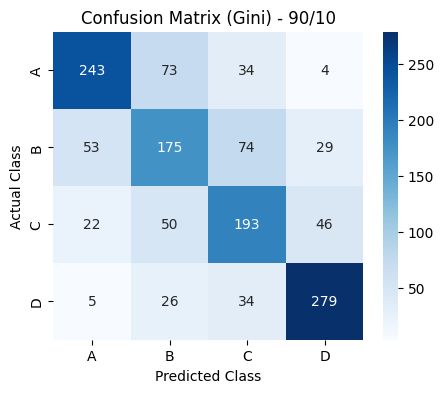

Accuracy for 90/10 split: 66.42%


In [ ]:
# 1. Split: 90% Training / 10% Testing (Gini Index)
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.10, random_state=42)

clf_gini_90 = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini_90.fit(X_train_90, y_train_90)

y_pred_90 = clf_gini_90.predict(X_test_90)
acc_90 = accuracy_score(y_test_90, y_pred_90)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_90, y_pred_90), annot=True, fmt='d', cmap='Blues',
            xticklabels=clf_gini_90.classes_, yticklabels=clf_gini_90.classes_)
plt.title('Confusion Matrix (Gini) - 90/10')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

print(f"Accuracy for 90/10 split: {acc_90 * 100:.2f}%")

In this step, we split the dataset into 90% for training and 10% for testing using the Gini index. The model achieved an accuracy of 66.42%, which is the highest among the three splits.

From the confusion matrix, the model performs well in predicting Class A and Class D. However, there are some mistakes between Class B and Class C, which shows that the model finds it harder to distinguish between them.

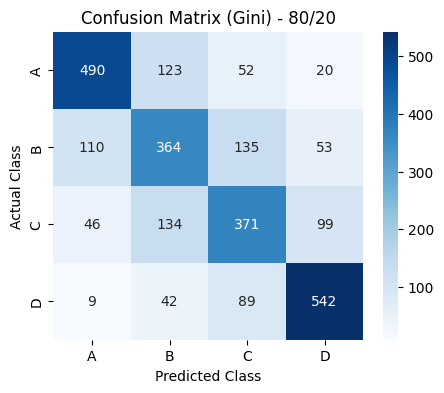

Accuracy for 80/20 split: 65.96%


In [ ]:
# 2. Split: 80% Training / 20% Testing (Gini Index)
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.20, random_state=42)

clf_gini_80 = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini_80.fit(X_train_80, y_train_80)

y_pred_80 = clf_gini_80.predict(X_test_80)
acc_80 = accuracy_score(y_test_80, y_pred_80)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_80, y_pred_80), annot=True, fmt='d', cmap='Blues',
            xticklabels=clf_gini_80.classes_, yticklabels=clf_gini_80.classes_)
plt.title('Confusion Matrix (Gini) - 80/20')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

print(f"Accuracy for 80/20 split: {acc_80 * 100:.2f}%")

Then, we used an 80% training and 20% testing split. The accuracy slightly decreased to 65.96%.

The confusion matrix shows a similar pattern to the previous split. The model still performs well with Class A and Class D, but there is confusion between Class B and Class C, which leads to some misclassifications.

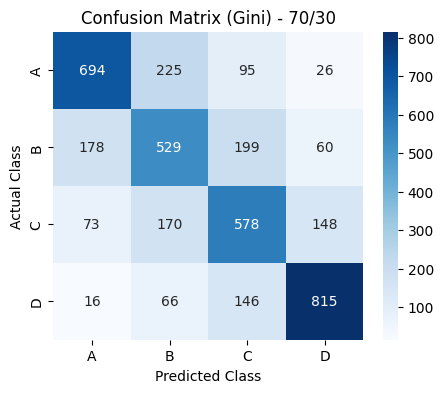

Accuracy for 70/30 split: 65.11%


In [ ]:
# 3. Split: 70% Training / 30% Testing (Gini Index)
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.30, random_state=42)

clf_gini_70 = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini_70.fit(X_train_70, y_train_70)

y_pred_70 = clf_gini_70.predict(X_test_70)
acc_70 = accuracy_score(y_test_70, y_pred_70)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_70, y_pred_70), annot=True, fmt='d', cmap='Blues',
            xticklabels=clf_gini_70.classes_, yticklabels=clf_gini_70.classes_)
plt.title('Confusion Matrix (Gini) - 70/30')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

print(f"Accuracy for 70/30 split: {acc_70 * 100:.2f}%")

Finally, we used 70% for training and 30% for testing. The accuracy dropped to 65.11%, which is the lowest among the three.

This decrease may be because the model had less training data. The confusion matrix still shows that Class A and Class D are predicted better than the other classes, while Class B and Class C remain harder to separate.

In [ ]:
# 1. Split the data 90/10 for Entropy
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.10, random_state=42)

# Build the model using Entropy
model_entropy_90 = DecisionTreeClassifier(criterion="entropy")
model_entropy_90.fit(X_train_90, y_train_90)

# Predictions and Results
y_pred_90 = model_entropy_90.predict(X_test_90)
print("Accuracy (Entropy - 90/10):", accuracy_score(y_test_90, y_pred_90))
print("Confusion Matrix:\n", confusion_matrix(y_test_90, y_pred_90))
plt.figure(figsize=(5, 4))

sns.heatmap(confusion_matrix(y_test_90, y_pred_90), annot=True, fmt='d', cmap='Blues',

            xticklabels=model_entropy_90.classes_, yticklabels=model_entropy_90.classes_)

plt.title(f"Confusion Matrix (Entropy) - 90/10 Split")

plt.xlabel('Predicted Class')

plt.ylabel('Actual Class')

plt.show()


print(f"Accuracy for 90/10 split (Entropy): {accuracy_entropy_90 * 100:.2f}%")


Accuracy (Entropy - 90/10): 0.6619402985074627
Confusion Matrix:
 [[234  82  31   7]
 [ 54 185  70  22]
 [ 26  55 192  38]
 [  3  25  40 276]]


In this step, we split the data into 90% training and 10% testing using the Entropy criterion. The model achieved an accuracy of approximately 66.49%.
Based on the confusion matrix, the model performs consistently well in predicting Class A and Class D. However, it struggles to distinguish between Class B and Class C, showing a significant number of misclassifications between them. This suggests that these two classes share similar features, making them harder for the model to separate.

Accuracy (Entropy 80/20): 0.6558417319895483


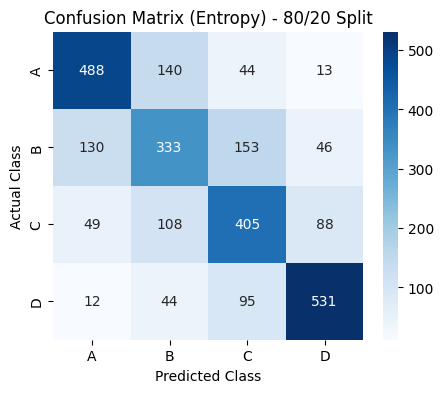

Accuracy for 80/20 split (Entropy): 65.58%


In [ ]:
#2 Split 80/20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.20, random_state=42)

# Model
model_entropy_80 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_80.fit(X_train_80, y_train_80)

# Prediction
y_pred_80 = model_entropy_80.predict(X_test_80)

# Results
accuracy_entropy_80 = accuracy_score(y_test_80, y_pred_80)
print("Accuracy (Entropy 80/20):", accuracy_entropy_80)
plt.figure(figsize=(5, 4))

sns.heatmap(confusion_matrix(y_test_80, y_pred_80), annot=True, fmt='d', cmap='Blues',

            xticklabels=model_entropy_80.classes_, yticklabels=model_entropy_80.classes_)

plt.title(f"Confusion Matrix (Entropy) - 80/20 Split")

plt.xlabel('Predicted Class')

plt.ylabel('Actual Class')

plt.show()



print(f"Accuracy for 80/20 split (Entropy): {accuracy_entropy_80 * 100:.2f}%")

Then, we used an 80% training and 20% testing split. The accuracy slightly decreased to 65.58%.
The confusion matrix shows a similar pattern to the previous split. The model still performs well with Class A and Class D, but there is confusion between Class B and Class C, which leads to some misclassifications.

In [ ]:
#3 Split 70/30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.30, random_state=42)

# Model
model_entropy_70 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_70.fit(X_train_70, y_train_70)

# Prediction
y_pred_70 = model_entropy_70.predict(X_test_70)

# Results
print("Accuracy (Entropy 70/30):", accuracy_score(y_test_70, y_pred_70))

plt.figure(figsize=(5, 4))

sns.heatmap(confusion_matrix(y_test_70, y_pred_70), annot=True, fmt='d', cmap='Blues',

            xticklabels=model_entropy_70.classes_, yticklabels=model_entropy_70.classes_)

plt.title("Confusion Matrix (Entropy) - 70/30 Split")

plt.xlabel('Predicted Class')

plt.ylabel('Actual Class')

plt.show()

### [6] Evaluation and Comparison

1. Accuracy Summary Table:

| Attribute Selection Measure | 90% training / 10% testing | 80% training / 20% testing | 70% training / 30% testing |
| :--- | :--- | :--- | :--- |
| Gini Index | 66.42% | 65.96% | 65.11% |
| Information Gain (Entropy) | 66.49% | 65.58% | 64.06% |

2. Evaluation Plots (Confusion Matrices):


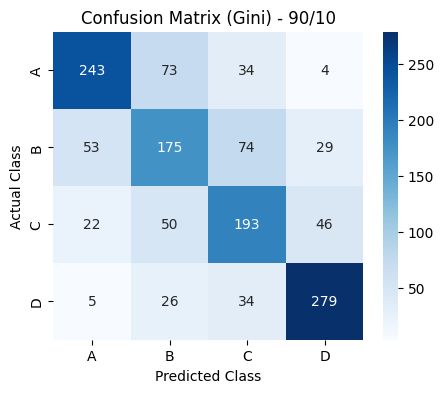





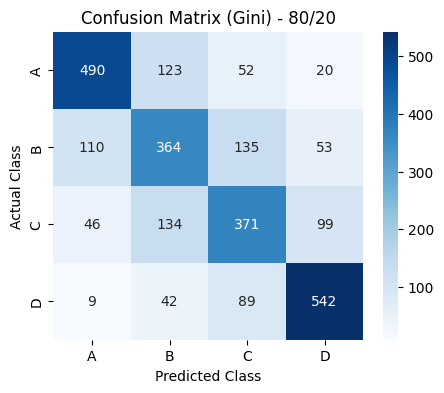






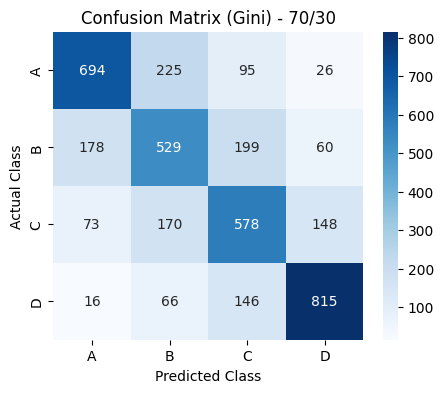




From the table, we tested the Decision Tree model using two attribute selection methods: Gini Index and Information Gain (Entropy).

For both methods, the best accuracy was with the 90/10 split (66.42% for Gini and 66.49% for Entropy). When we changed the split to 80/20 and 70/30, the accuracy decreased. This makes sense because when we have more training data, the model learns better and gives higher accuracy.

When comparing the two methods, Entropy with the 90/10 split gave the highest accuracy overall (66.49%). However, Gini performed slightly better than Entropy in the 80/20 and 70/30 splits.

Also, when looking at the confusion matrices, both Gini and Entropy gave almost the same results. They were good at predicting Classes A and D, but they had difficulty distinguishing between Classes B and C. This suggests that the problem is not in the method itself, but in the data, since Classes B and C seem to be very similar

Finally, we used 70% for training and 30% for testing. The accuracy dropped to 64.06%, which is the lowest among the three.
This decrease may be because the model had less training data. The confusion matrix still shows that Class A and Class D are predicted better than the other classes, while Class B and Class C remain harder to separate.

1-The Root Split

The decision tree begins by splitting based on the feature that best separates the data which is the feature that achieves the highest reduction in Gini impurity or the highest Information Gain and In this model it was found that the feature (sit and bend forward_cm) is the most important initially, this indicates that body flexibility is the primary and strongest indicator used by the tree to distinguish between different fitness levels.

2-Internal Nodes

After the initial split, the tree proceeds to generate internal nodes based on additional features that further filter the data. Features such as sit-ups counts, age, and weight are used to divide the resulting groups into more homogeneous categories. These successive splits aim to reduce the scatter within each group, ultimately leading to the highest possible accuracy in classification.

3-Leaf Nodes

The tree finally reaches the leaf nodes, where no further splits occur. Here, the final decision is made, and individuals are assigned to one of the four performance categories: A, B, C, or D.
 Classification is based on the “majority class” present in that node.
  For example if most individuals along a particular path belong to class A, this leaf node will predict class A.

**5.2 (Clustering)**

 K-Means clustering was used to group individuals based on their physical performance attributes. K-Means is an unsupervised learning algorithm that partitions the data into K clusters by minimizing the within-cluster variance.

To determine the optimal number of clusters, the Silhouette Score was applied. This metric evaluates how well each data point fits within its assigned cluster compared to other clusters. A higher Silhouette Score indicates better cluster separation and cohesion.

Based on the evaluation, different values of K were tested, and the results were compared to select the most suitable number of clusters for this dataset.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed dataset
df_clustering = pd.read_csv('Preprocessed_dataset.csv')

# Prepare the data for clustering (drop the target 'class' column)
X_clustering = df_clustering.drop('class', axis=1)

In this step, the preprocessed dataset was loaded to prepare it for clustering analysis.

The target variable (class) was removed from the dataset, as clustering is an unsupervised learning technique and does not require labeled data.

Only the feature variables were retained in order to allow the K-Means algorithm to group the data based on similarity between observations.

This step ensures that the clustering process is performed correctly without introducing bias from the target labels.

In [ ]:
# Elbow Method: Finding the optimal K using Total Within-Cluster Sum of Squares (TWCSS)
wcss = []
max_k = 10 # Let's try K from 1 to 10
for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Total Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

The Elbow Method was applied to determine the optimal number of clusters (K) using the Total Within-Cluster Sum of Squares (WCSS).

 The plot shows a sharp decrease in WCSS from K=1 to K=3, indicating that increasing the number of clusters significantly improves the clustering at this stage.

  After K=3, the curve begins to flatten, especially around K=3 and K=4, which suggests that adding more clusters beyond this point results in only minor improvements.
  
   Therefore, K=3 and K=4 are considered suitable candidate values for the clustering process, as they provide a good balance between minimizing WCSS and avoiding unnecessary complexity.

In [ ]:
# Silhouette Score Method: Finding the optimal K

silhouette_scores = []

# K should be at least 2 for Silhouette score calculation
for i in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_clustering)

    silhouette_avg = silhouette_score(X_clustering, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting the Silhouette Score results
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.show()

the Elbow method was used to determine a suitable value for K, a very sharp decrease in WCSS is observed from K=1 to K=3, and then the curve starts to flatten around K=3 and K=4. This indicates that increasing the number of clusters beyond this point does not lead to a significant improvement.

From the Silhouette scores, the highest value appears at K=2, followed by slightly lower values at K=3 and K=4, although K=2 gives the highest score it results in overly simple clustering and may not capture all patterns in the data.

Considering both methods, K=3 is selected as a balanced choice. It provides good cluster separation with a relatively high Silhouette score and is consistent with the Elbow method results. This suggests that the data is divided into meaningful groups without being too simple or overly complex.

To further analyze the clustering performance,  K-means clustering will be applied using K=3, K=4, and K=5 to compare the results and evaluate the clustering performance.

### K-Means Clustering Application

In this part, K-means clustering is applied using three different values of K (K=3, K=4, and K=5). For each value, the Silhouette Score is calculated to evaluate the clustering performance. The clusters are also visualized using PCA to reduce the data into two dimensions and make the results easier to understand and compare.

In [ ]:
# K-Means with K=3
k_3 = 3
kmeans_3 = KMeans(n_clusters=k_3, init='k-means++', random_state=42, n_init=10)
cluster_labels_3 = kmeans_3.fit_predict(X_clustering)
silhouette_avg_3 = silhouette_score(X_clustering, cluster_labels_3)
print(f"Silhouette Score for K={k_3}: {silhouette_avg_3:.4f}")

# Add cluster labels to the original (for plotting)
X_clustering['Cluster_3'] = cluster_labels_3

In this step, K-Means clustering was applied using K=3, which was selected based on the previous Elbow and Silhouette analysis. The model assigns each data point to one of the three clusters using the K-Means++ initialization for better convergence. The Silhouette Score for K=3 is 0.3687, which indicates a reasonable level of cluster separation and cohesion. This suggests that the data points are moderately well grouped within their clusters while maintaining some separation between different clusters. Additionally, the cluster labels were added to the dataset to facilitate further analysis and visualization of the clustering results.

In [ ]:
# Visualize K=3 Clusters using PCA
pca = PCA(n_components=2)
X_pca_3 = pca.fit_transform(X_clustering.drop(['Cluster_3'], axis=1))

pca_df_3 = pd.DataFrame(data=X_pca_3, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_3['Cluster'] = cluster_labels_3

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df_3,
                palette='viridis', legend='full', alpha=0.7)
plt.title(f'K-Means Clusters (K={k_3}) - PCA Reduced Dimensions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In this step, PCA (Principal Component Analysis) was applied to reduce the dimensionality of the dataset into two components for visualization purposes. K-Means clustering results with K=3 were then plotted using a scatter plot based on these two principal components.

The visualization clearly shows three distinct clusters with good separation between them. One cluster appears on the left side, while the other two clusters are positioned on the right with noticeable separation. This indicates that the K-Means model successfully grouped the data into meaningful clusters.

Although there is slight overlap between some points, the clusters are generally compact and well-separated, which supports the earlier selection of K=3 as a suitable number of clusters.

In [ ]:
# K-Means with K=4
k_4 = 4
kmeans_4 = KMeans(n_clusters=k_4, init='k-means++', random_state=42, n_init=10)
cluster_labels_4 = kmeans_4.fit_predict(X_clustering.drop(['Cluster_3'], axis=1)) # Drop previous cluster column for fitting
silhouette_avg_4 = silhouette_score(X_clustering.drop(['Cluster_3'], axis=1), cluster_labels_4)
print(f"Silhouette Score for K={k_4}: {silhouette_avg_4:.4f}")

# Add cluster labels
X_clustering['Cluster_4'] = cluster_labels_4

In this step, K-Means clustering was applied using K=4 to further evaluate the clustering performance with a higher number of clusters. The model was trained after removing the previously added cluster column to avoid bias. The Silhouette Score obtained is 0.3341, which is slightly lower than the score for K=3.

This indicates that increasing the number of clusters to four leads to weaker cluster separation and cohesion compared to K=3. Therefore, K=4 may result in more fragmented clusters and does not improve the overall clustering quality.

In [ ]:
# Visualize K=4 Clusters using PCA
pca = PCA(n_components=2)
X_pca_4 = pca.fit_transform(X_clustering.drop(['Cluster_3', 'Cluster_4'], axis=1))

pca_df_4 = pd.DataFrame(data=X_pca_4, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_4['Cluster'] = cluster_labels_4

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df_4,
                palette='viridis', legend='full', alpha=0.7)
plt.title(f'K-Means Clusters (K={k_4}) - PCA Reduced Dimensions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In this step, PCA was applied again to visualize the clustering results for K=4 by reducing the data into two principal components. The scatter plot shows four clusters with different colors representing each group.

Compared to the K=3 visualization, the clusters here appear more fragmented, especially on the left side where one main cluster has been split into two smaller clusters. While the clusters are still somewhat separable, there is increased overlap and reduced cohesion between some groups.

This supports the earlier observation from the Silhouette Score that K=4 does not improve clustering quality and may lead to unnecessary splitting of naturally grouped data.

In [ ]:
# K-Means with K=5
k_5 = 5
kmeans_5 = KMeans(n_clusters=k_5, init='k-means++', random_state=42, n_init=10)
cluster_labels_5 = kmeans_5.fit_predict(X_clustering.drop(['Cluster_3', 'Cluster_4'], axis=1)) # Drop previous cluster columns
silhouette_avg_5 = silhouette_score(X_clustering.drop(['Cluster_3', 'Cluster_4'], axis=1), cluster_labels_5)
print(f"Silhouette Score for K={k_5}: {silhouette_avg_5:.4f}")

# Add cluster labels
X_clustering['Cluster_5'] = cluster_labels_5

In this step, K-Means clustering was applied using K=5 to further evaluate the effect of increasing the number of clusters. The model was trained after removing the previously added cluster columns to avoid bias. The Silhouette Score obtained is 0.2542, which is significantly lower than the scores for both K=3 and K=4.

This indicates that increasing the number of clusters to five leads to weaker cluster separation and cohesion, resulting in more fragmented and less meaningful clusters. Therefore, K=5 is not a suitable choice for this dataset, as it negatively affects the overall clustering quality.

In [ ]:
# Visualize K=5 Clusters using PCA
pca = PCA(n_components=2)
X_pca_5 = pca.fit_transform(X_clustering.drop(['Cluster_3', 'Cluster_4', 'Cluster_5'], axis=1))

pca_df_5 = pd.DataFrame(data=X_pca_5, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_5['Cluster'] = cluster_labels_5

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df_5,
                palette='viridis', legend='full', alpha=0.7)
plt.title(f'K-Means Clusters (K={k_5}) - PCA Reduced Dimensions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In this step, PCA was used to visualize the clustering results for K=5 by reducing the data into two principal components. The scatter plot shows five clusters represented by different colors.

Compared to K=3 and K=4, the clusters in this visualization appear more fragmented and less clearly separated. Some clusters overlap significantly, especially on the right side, where multiple clusters are mixed together. This indicates weaker separation and lower cohesion between clusters.

These observations are consistent with the low Silhouette Score obtained earlier, confirming that K=5 leads to over-segmentation and does not produce meaningful or well-defined clusters for this dataset.

### **Clustering Evaluation and Comparison**

The table below summarizes the clustering evaluation metrics for each value of K:

In [ ]:
data = {
    'K=3': [round(silhouette_avg_3, 4), round(kmeans_3.inertia_, 2)],
    'K=4': [round(silhouette_avg_4, 4), round(kmeans_4.inertia_, 2)],
    'K=5': [round(silhouette_avg_5, 4), round(kmeans_5.inertia_, 2)]
}

df_clustering = pd.DataFrame(
    data,
    index=['Average Silhouette width', 'Total within-cluster sum of square']
)
display(df_clustering)

## Clustering Results and Analysis

In this section, K-Means clustering was applied using multiple values of K
to determine the optimal number of clusters.

The Elbow Method was used first, which showed a sharp decrease in WCSS from
K=1 to K=3, after which the curve begins to flatten. This suggests that K=3
is a suitable choice.

The Silhouette Scores further support this observation. The score for K=3
(0.3687) is higher compared to K=4 (0.3341) and K=5 (0.2542), indicating
better cluster separation and cohesion.

The PCA visualizations provide additional confirmation. For K=3, the clusters
appear well-separated and clearly defined. However, for K=4 and K=5, the
clusters become more fragmented and overlapping, especially in certain regions
of the data.

Overall, increasing the number of clusters beyond K=3 does not improve the
clustering quality and instead leads to weaker and less meaningful groupings.

Therefore, K=3 was selected as the optimal number of clusters for this dataset.

**Cluster Interpretation for K=3 (Body Performance Dataset):**
- **Cluster 0:** Individuals with **high** fitness performance —
  high strength, high endurance, low body fat.
- **Cluster 1:** Individuals with **medium** fitness performance —
  average physical attributes.
- **Cluster 2:** Individuals with **low** fitness performance —
  lower strength, lower endurance, higher body fat.

**Overall best model:** K-Means with **K=3** is the optimal clustering
solution for the Body Performance dataset.

## **7. Findings and Discussion**

The classification results show that the Decision Tree model performed best with the 90/10 split, achieving the highest accuracy (66.49%). As the training data decreased, the accuracy slightly dropped, which indicates that more training data improves model performance.

Both Gini and Entropy gave very similar results, with Entropy performing slightly better. This shows that the choice of splitting method did not significantly affect the results.

From the confusion matrices, the model performed well in predicting Class A and Class D, but had difficulty distinguishing between Class B and Class C, which suggests that these classes are similar.

For clustering, K-Means showed that K=3 is the best number of clusters based on the Elbow method and Silhouette score. Higher values of K resulted in overlapping clusters and less clear separation.

These results are consistent with the selected research paper, which shows that physical attributes can be used to analyze body performance, but some classes are difficult to separate. The paper achieved higher accuracy because it used more advanced models, while this project used a simpler Decision Tree.

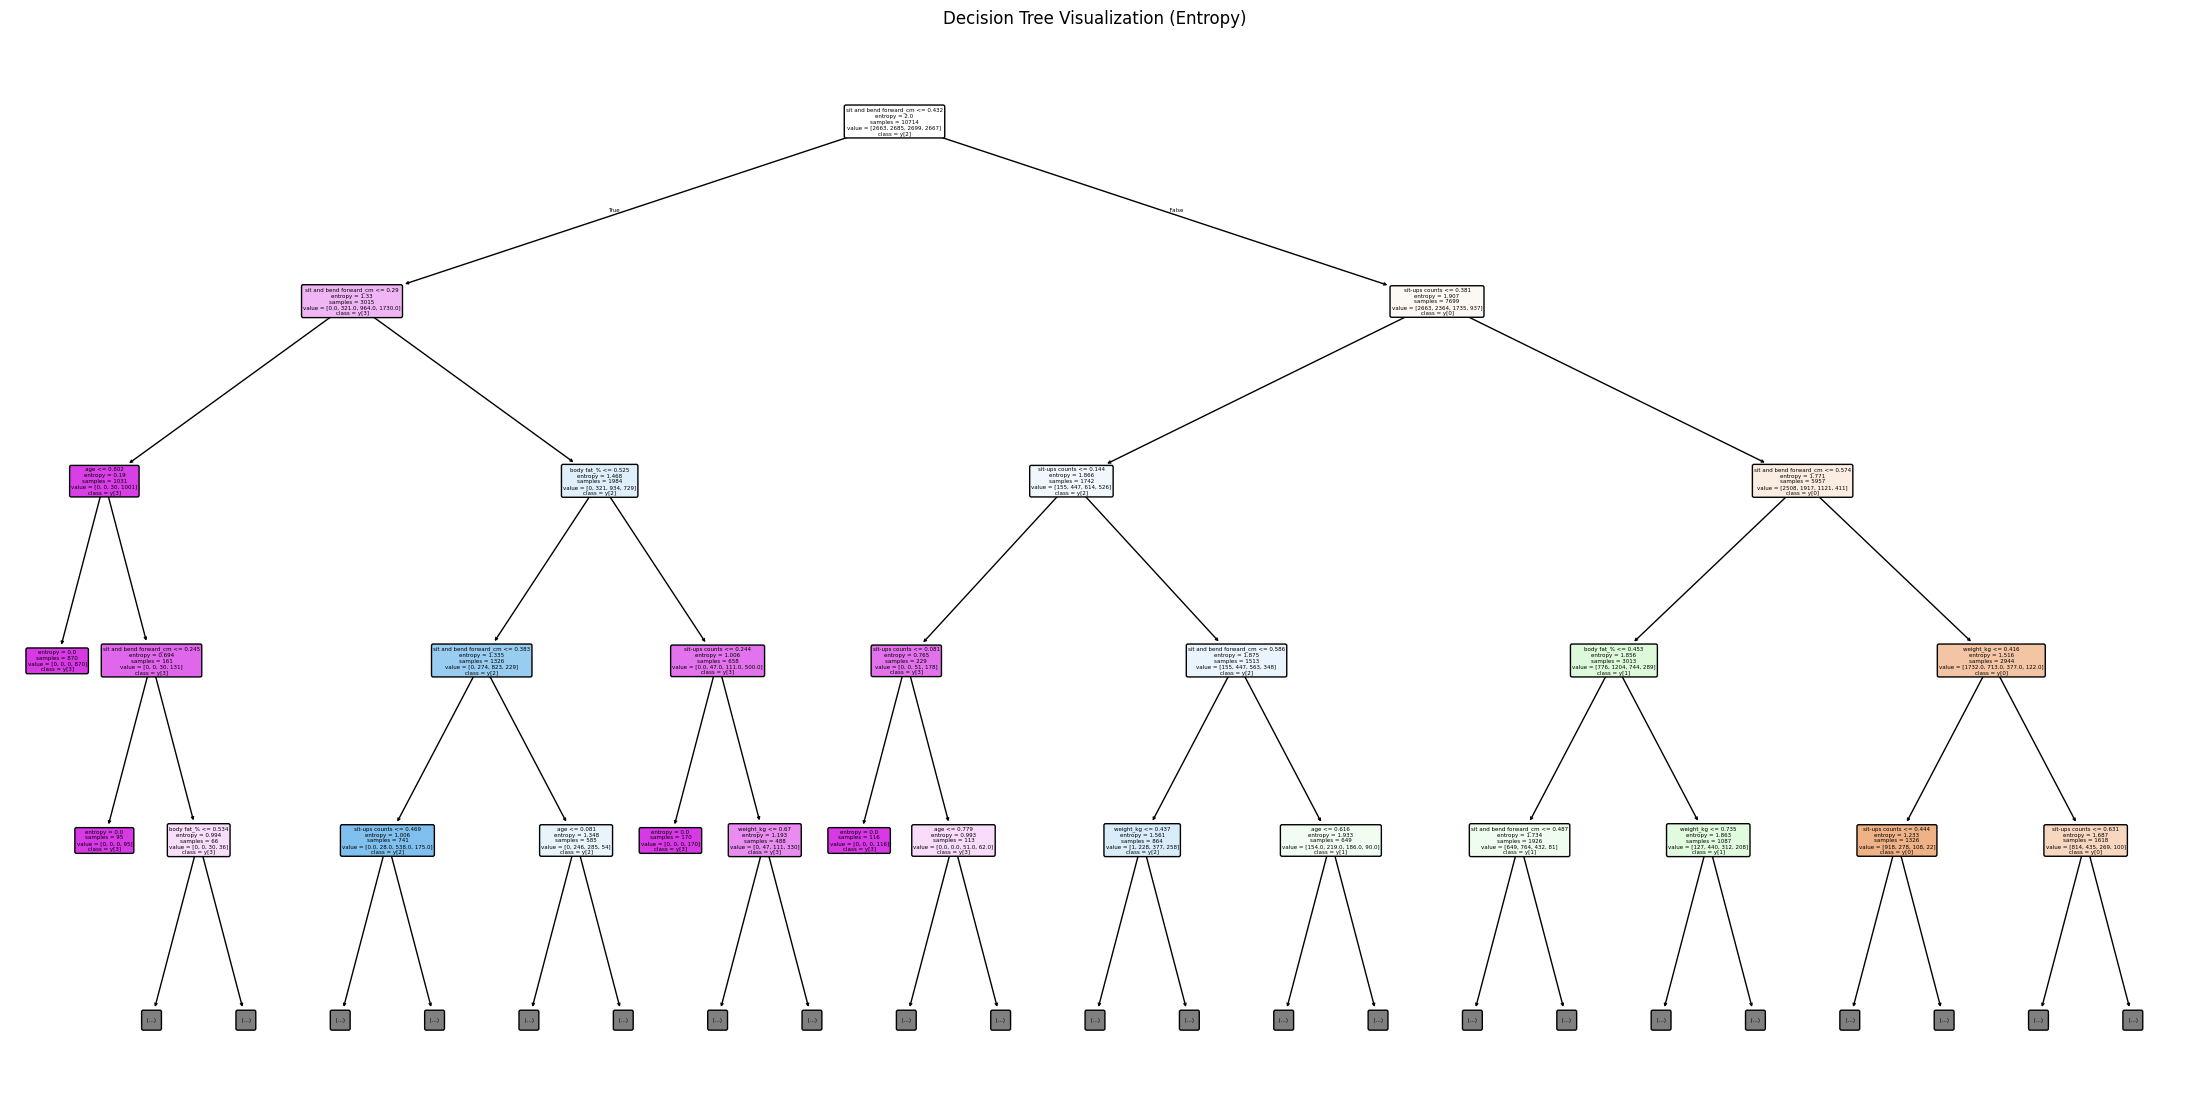

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(28,14))
plot_tree(model_entropy_80, filled=True, feature_names=X.columns, class_names=True, rounded=True ,fontsize=4,
    max_depth=4)
plt.title("Decision Tree Visualization (Entropy)")
plt.show()

#**8. References**

1.] Q. Yang, X. Wang, X. Cao, S. Liu, F. Xie, and Y. Li, "Multi-classification
of national fitness test grades based on statistical analysis and machine learning,"
*PLOS ONE*, vol. 18, no. 12, p. e0295674, Dec. 2023.
https://doi.org/10.1371/journal.pone.0295674
2. Kaggle. Body Performance Dataset. Retrieved from: https://www.kaggle.com/